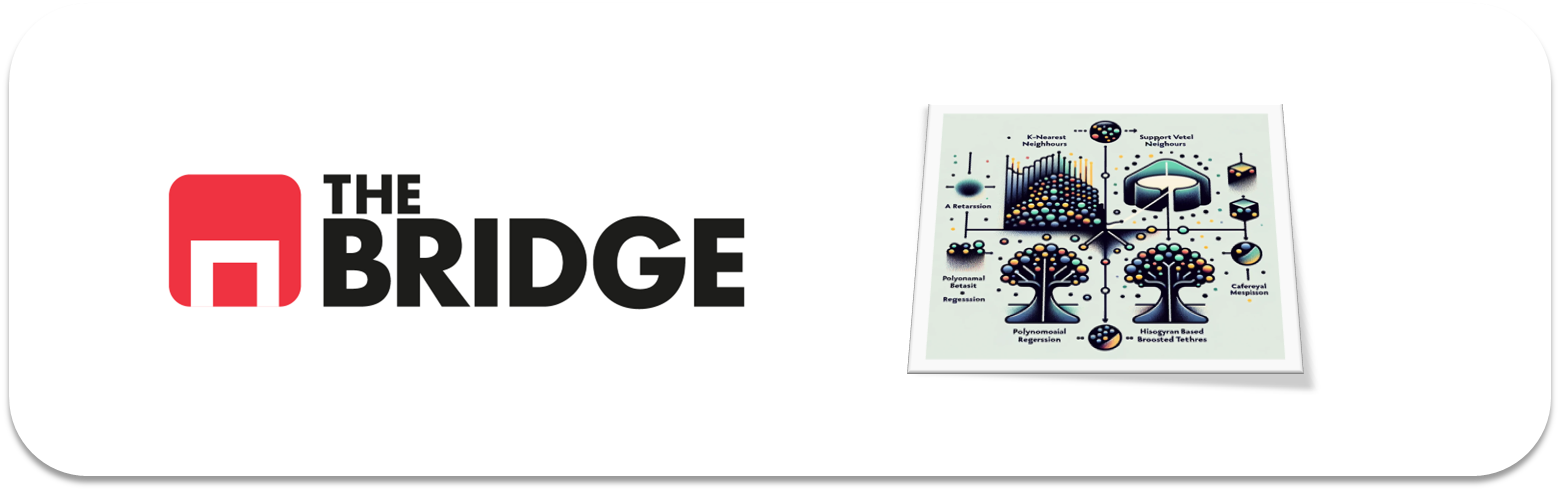

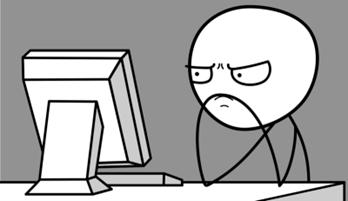

Para ejercitarte y afianzar lo aprendido sobre **Otros Modelos de aprendizaje supervisado**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

## PARTE 1. KNN

En la primera parte  vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating (ojo, no el sentimiento), en función del sentimiento del comentario y su valor y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

### Ejercicio 1

Lee el archivo de entrada "reviews_sentiment.csv" y carga su contenido en un dataframe. Muestras sus primeras líneas, su información general y define una variable "target" asignándole el nombre de la columna que contenga el target del problema. 

In [2]:
df = pd.read_csv("./data/reviews_sentiment.csv", sep=None, engine="python")
df.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    257 non-null    str    
 1   Review Text     257 non-null    str    
 2   wordcount       257 non-null    int64  
 3   titleSentiment  231 non-null    str    
 4   textSentiment   257 non-null    str    
 5   Star Rating     257 non-null    int64  
 6   sentimentValue  257 non-null    float64
dtypes: float64(1), int64(2), str(4)
memory usage: 29.3 KB


### Ejericicio 2

Muestra la distribución del target y coméntala brevemente.

In [6]:
TARGET = "Star Rating"
df["Star Rating"].value_counts()

Star Rating
5    88
3    78
1    37
4    30
2    24
Name: count, dtype: int64

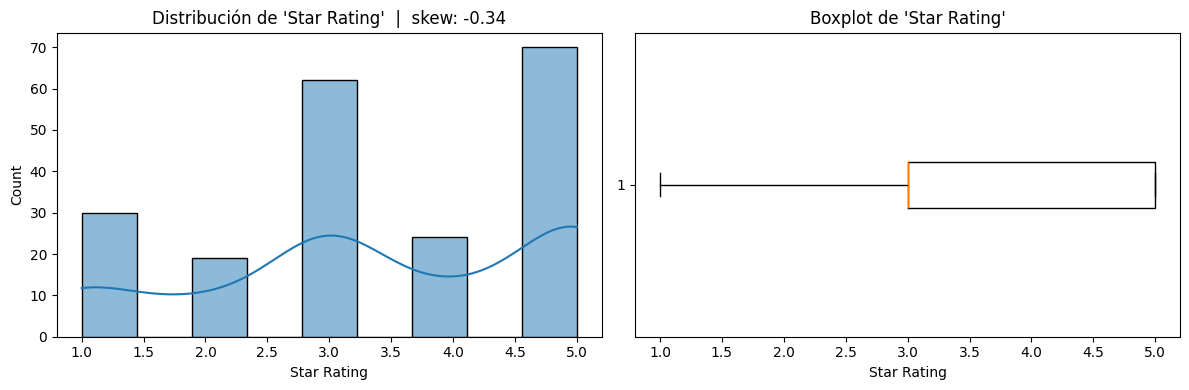

Star Rating
5    34.1
3    30.2
1    14.6
4    11.7
2     9.3
Name: proportion, dtype: float64


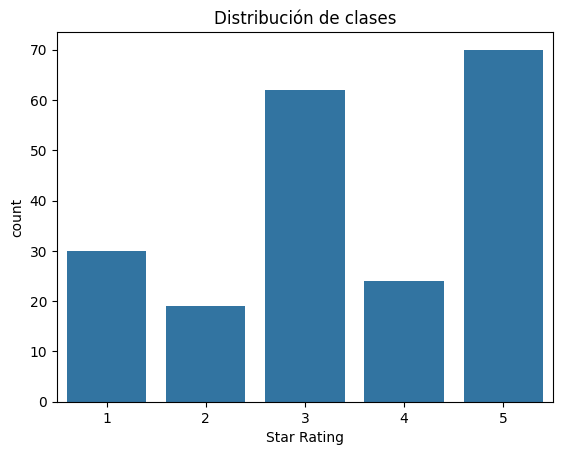

In [13]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con curva de densidad
sns.histplot(y_train, kde=True, ax=axes[0])
axes[0].set_title(f"Distribución de '{TARGET}'  |  skew: {y_train.skew():.2f}")

# Boxplot para ver outliers
axes[1].boxplot(y_train.dropna(), vert=False)
axes[1].set_title(f"Boxplot de '{TARGET}'")
axes[1].set_xlabel(TARGET)

plt.tight_layout()
plt.show()

# Para clasificación — descomenta esto:
sns.countplot(x=y_train)
plt.title('Distribución de clases')
print(y_train.value_counts(normalize=True).mul(100).round(1))

### Ejercicio 3

Deshazte de la columna "titleSentiment" que tiene nulos y no vamos a emplearla.

In [17]:
df.drop(columns="titleSentiment", inplace=True)

KeyError: "['titleSentiment'] not found in axis"

In [15]:
df

,Review Title,Review Text,wordcount,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,1,-0.651784
...,...,...,...,...,...,...
252,Muy buena aplicacion,Muy buena genial,3,positive,5,2.814818
253,Buena,Genial,1,positive,5,2.924393
254,Wuau,Genial,1,positive,5,2.924393
255,Muy buena,Genial,1,positive,5,2.924393


### Ejercicio 4

Haz el split en train y test.

In [18]:
# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)

In [19]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20 % para test
    random_state=42,     # Fija la semilla → resultados reproducibles
    stratify=y         # Descomentar en clasificación con clases desbalanceadas
)

print(f"Train: {X_train.shape[0]} filas  ({X_train.shape[0]/len(df)*100:.0f} %)")
print(f"Test:  {X_test.shape[0]} filas  ({X_test.shape[0]/len(df)*100:.0f} %)")

Train: 205 filas  (80 %)
Test:  52 filas  (20 %)


### Ejercicio 5

Muestra la descripción de las variables que consideres numéricas (justificando tu elección) y sus histogramas. ¿Hay que aplicar alguna transformación o tratamiento? (Recuerda que vamos a emplear un KNN)

In [20]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 205 entries, 8 to 168
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Review Title    205 non-null    str    
 1   Review Text     205 non-null    str    
 2   wordcount       205 non-null    int64  
 3   textSentiment   205 non-null    str    
 4   sentimentValue  205 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 20.1 KB


In [21]:
features_num = ["wordcount", "sentimentValue"]
features_num

['wordcount', 'sentimentValue']

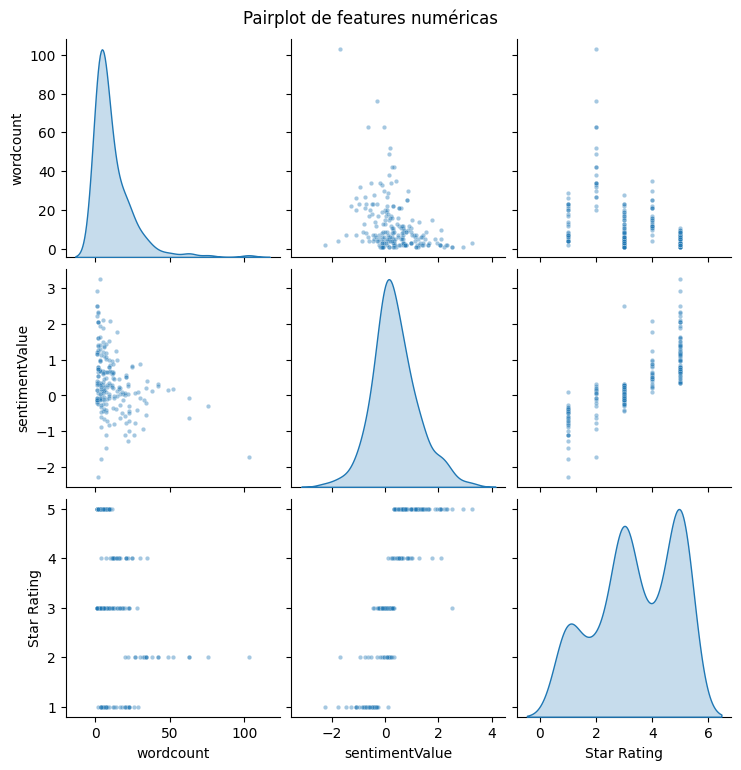

In [22]:
# Seleccionamos las features numéricas y añadimos la target
cols_plot = X_train.select_dtypes('number').columns.tolist()[:6]  # max 6 para legibilidad

sns.pairplot(
    X_train[cols_plot].join(y_train),
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 10}
)
plt.suptitle('Pairplot de features numéricas', y=1.02)
plt.show()

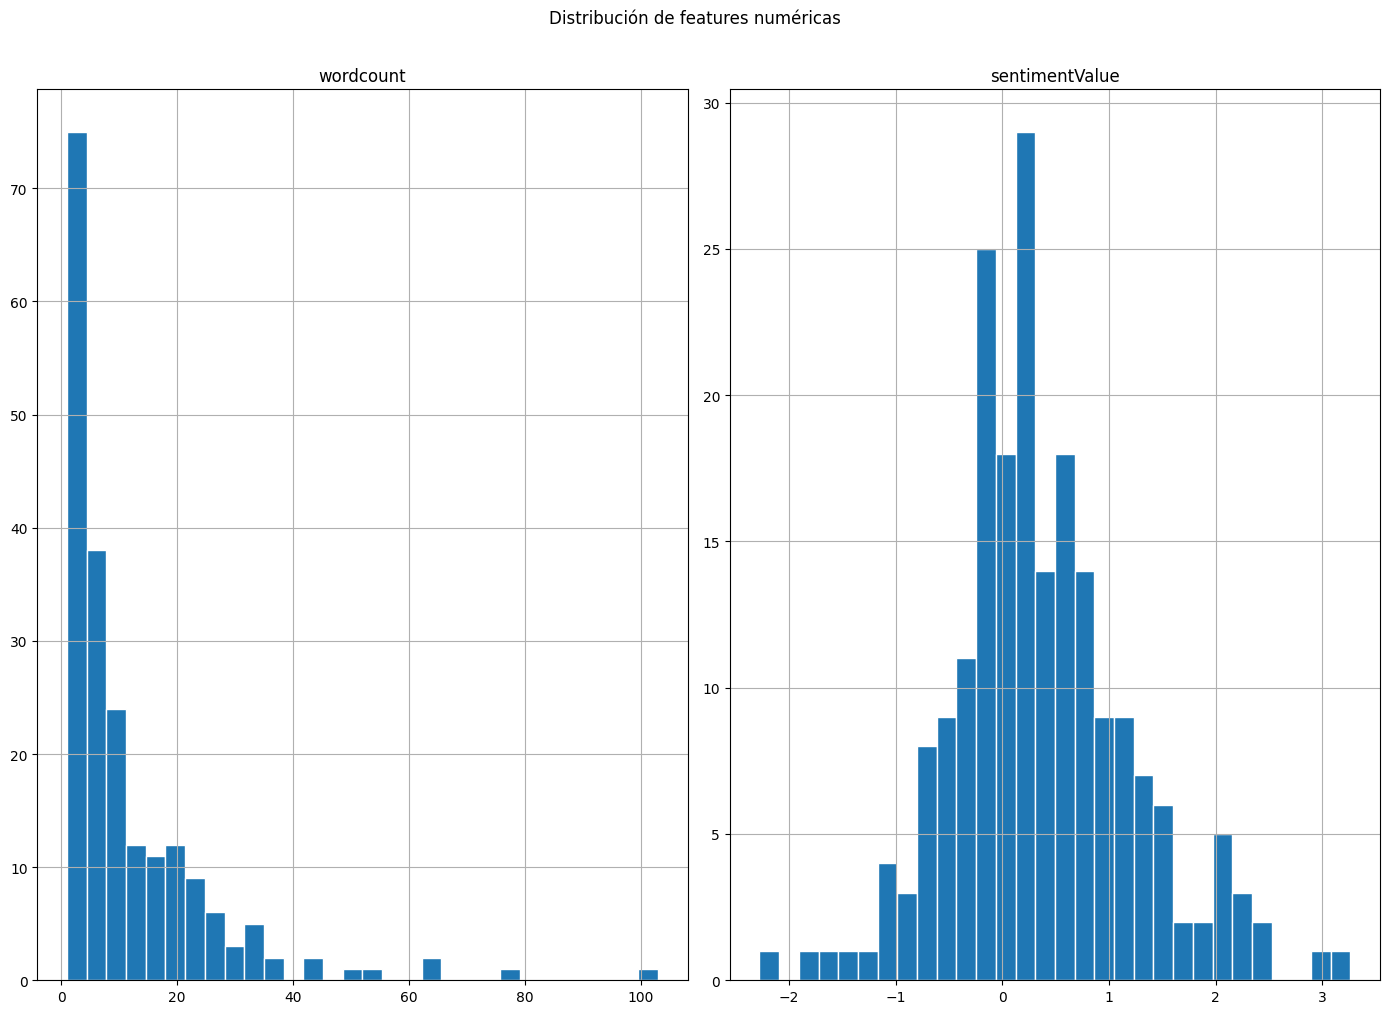

Skewness por feature:
wordcount         2.942530
sentimentValue    0.416094


In [18]:
X_train.select_dtypes('number').hist(figsize=(14, 10), bins=30, edgecolor='white')
plt.suptitle('Distribución de features numéricas', y=1.01)
plt.tight_layout()
plt.show()

# Skewness de cada feature numérica
skew = X_train.select_dtypes('number').skew().sort_values(key=abs, ascending=False)
print("Skewness por feature:")
print(skew.to_string())

In [23]:
X_train.describe()

,wordcount,sentimentValue
count,205.000000,205.000000
mean,11.560976,0.363753
std,13.768479,0.857533
min,1.000000,-2.276469
25%,3.000000,-0.116132
50%,7.000000,0.246869
75%,16.000000,0.794211
max,103.000000,3.264579


In [24]:
X_train["wordcount"] = np.log(X_train["wordcount"])
X_test["wordcount"] = np.log(X_test["wordcount"])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cols_to_scale = ["wordcount", "sentimentValue"]

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [26]:
X_train.describe()

,wordcount,sentimentValue
count,2.050000e+02,2.050000e+02
mean,1.516402e-16,4.332578e-17
std,1.002448e+00,1.002448e+00
min,-1.733380e+00,-3.086395e+00
25%,-7.243139e-01,-5.609803e-01
50%,5.392201e-02,-1.366363e-01
75%,8.132192e-01,5.032015e-01
max,2.523579e+00,3.391039e+00


### Ejercicio 6

Muestra la distribución frecuencial de las variables que consideres categóricas. ¿Habrías que hacerles algún tipo de tratamiento?

In [27]:

def describe_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Genera un resumen estadístico descriptivo de un DataFrame.

    Argumentos:
        df (pd.DataFrame): DataFrame a analizar.

    Retorna:
        pd.DataFrame: DataFrame con una fila por columna del input y las
        siguientes columnas: 'tipo', 'porcentaje_nulos', 'valores_unicos',
        'porcentaje_cardinalidad'.
        Retorna None si el input no es un DataFrame válido.
    """
    
    # Comprobación de que si es un DataFrame
    if not isinstance(df, pd.DataFrame):
        print("Error: el objeto proporcionado no es un DataFrame.")
        return None

    # Crear el DataFrame resultado
    resultado = pd.DataFrame(index=df.columns)

    # Tipo de dato
    resultado["tipo"] = df.dtypes.astype(str)

    # Porcentaje de nulos
    resultado["porcentaje_nulos"] = (df.isna().mean() * 100).round(2)

    # Valores únicos
    resultado["valores_unicos"] = df.nunique()

    # Porcentaje de cardinalidad
    resultado["porcentaje_cardinalidad"] = ((df.nunique() / len(df)) * 100).round(2)


    return resultado


In [28]:
describe_df(df)

,tipo,porcentaje_nulos,valores_unicos,porcentaje_cardinalidad
Review Title,str,0.0,186,72.37
Review Text,str,0.0,241,93.77
wordcount,int64,0.0,42,16.34
textSentiment,str,0.0,2,0.78
Star Rating,int64,0.0,5,1.95
sentimentValue,float64,0.0,241,93.77


In [29]:
df["textSentiment"].value_counts()


textSentiment
positive    211
negative     46
Name: count, dtype: int64

In [30]:
X_train["textSentiment"] = X_train["textSentiment"].map({"positive": 1, "negative": 0})
X_test["textSentiment"] = X_test["textSentiment"].map({"positive": 1, "negative": 0})


In [31]:
X_train

,Review Title,Review Text,wordcount,textSentiment,sentimentValue
8,Ta to guapa.,Va de escándalo,1.062988,0,-1.319833
70,ES MUY BUENA,A…,-1.733380,1,-0.674326
16,Muy bien ..pero,…,1.259154,0,-1.716337
84,Problema,"Me funcionaba perfectamente, y era super util,...",1.327222,0,-0.900562
33,Demasiados feaute,A ver......tiene muchísimos ….no mola nada,2.072054,0,-1.175983
...,...,...,...,...,...
154,Me encanta!,"Buenisima aplicación, la deberían de tener … M...",1.390591,1,0.592863
67,👍,😂👍,-1.733380,1,-0.588719
130,Ahora si va mucho mejor,La nueva actualización funciona bien. Ahora sí,0.053922,1,-0.300012
51,Mola,Mola,-1.733380,1,-0.522796


In [39]:
X_train.drop(columns=["Review Title", "Review Text"], inplace=True)

In [40]:
X_test.drop(columns=["Review Title", "Review Text"], inplace=True)

KeyError: "['Review Title', 'Review Text'] not found in axis"

### Ejercicio 7

En un modelado completo habríamos comprobado la relación entre las features y el targer, para estos ejercicios, las vamos a incluir sí o si. Haz el tratamiento de features, haciendo la conversión ordinal de la binaria (usa 1 para positive y 0 para negative) y aplicando el escalado que creas más conveniente en consecuencia para las numéricas

In [41]:
X_train

,wordcount,textSentiment,sentimentValue
8,1.062988,0,-1.319833
70,-1.733380,1,-0.674326
16,1.259154,0,-1.716337
84,1.327222,0,-0.900562
33,2.072054,0,-1.175983
...,...,...,...
154,1.390591,1,0.592863
67,-1.733380,1,-0.588719
130,0.053922,1,-0.300012
51,-1.733380,1,-0.522796


### Ejercicio 8

Crea el juego X,y de train y test. Carga el modelo, instancialo con un k=5 para empezar y entrénalo.

In [42]:
# . Instanciar el modelo con k=5
knn = KNeighborsClassifier(n_neighbors=5)

# . Entrenar
knn.fit(X_train, y_train)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


### Ejercicio 9

Evalúalo contra el propio train y contra test, ¿qué puedes decir de los resultados?

In [43]:
train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)

train_score, test_score


(0.8878048780487805, 0.9038461538461539)

### Ejercicio 10

Vamos a "ajustar a mano" el valor de K, probando diferentes valores entre 1 y 20. Para ello haz un bucle que cambie el valor de K y obtenga mediante validación cruzada el valor del "balanced accuracy" para cada "modelo" y se quede con el k que mejor métrica obtenga. Luego entrena un modelo para ese k y evalúalo contra el target.

In [44]:

from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score
import numpy as np

# Métrica
scorer = make_scorer(balanced_accuracy_score)

k_values = range(1, 21)
scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring=scorer).mean()
    scores.append(cv_score)

# Mejor k
best_k = k_values[np.argmax(scores)]
best_score = max(scores)

best_k, best_score


(4, np.float64(0.8385128205128206))

In [45]:
# . Instanciar el modelo con k=4
knn = KNeighborsClassifier(n_neighbors=4)

# . Entrenar
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",4
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [46]:
train_score = knn.score(X_train, y_train)
test_score = knn.score(X_test, y_test)

train_score, test_score


(0.9170731707317074, 0.8653846153846154)

### Ejercicio 11

Repasa la ficha de KNN o la documentación de sklearn y, usando un grid y una estrategia completa (GridSearch), busca la mejor combinación de k y weights que puedas, empleando de nuevo "balanced_accuracy" como métrica.

In [47]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score

# Definir el modelo base
knn = KNeighborsClassifier()

# Definir la métrica
scorer = make_scorer(balanced_accuracy_score)

# Definir la rejilla de hiperparámetros
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"]
}

# Configurar el GridSearch
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)

# Entrenar el GridSearch
grid.fit(X_train, y_train)

# Mostrar el mejor modelo
grid.best_params_, grid.best_score_


({'n_neighbors': 4, 'weights': 'uniform'}, np.float64(0.8385128205128206))

In [48]:
# Entrenar el modelo final con los mejores hiperparámetros
knn_final = KNeighborsClassifier(n_neighbors=4, weights='uniform')
knn_final.fit(X_train, y_train)

# Evaluación
train_score = knn_final.score(X_train, y_train)
test_score = knn_final.score(X_test, y_test)

train_score, test_score


(0.9170731707317074, 0.8653846153846154)